In [4]:
import pandas as pd
import os
import json

def parse_json_stream(file_path):
    """
    Parses a file containing a stream of concatenated JSON objects.
    """
    with open(file_path, 'r') as f:
        content = f.read()
    
    decoder = json.JSONDecoder()
    objects = []
    pos = 0
    # Skip leading whitespace
    while pos < len(content) and content[pos].isspace():
        pos += 1
    
    while pos < len(content):
        try:
            obj, pos = decoder.raw_decode(content, pos)
            objects.append(obj)
            # Skip whitespace between objects
            while pos < len(content) and content[pos].isspace():
                pos += 1
        except json.JSONDecodeError:
            # Handle cases where decoding might fail, e.g., trailing characters
            break
            
    return objects

# Directory containing the JSON files
data_dir = 'infer_metrics'
all_metrics = []

# Check if the directory exists
if os.path.isdir(data_dir):
    # Iterate over each file in the directory
    for filename in os.listdir(data_dir):
        if filename.endswith('.json'):
            file_path = os.path.join(data_dir, filename)
            # Parse the stream of JSON objects from the file
            metrics_from_file = parse_json_stream(file_path)
            all_metrics.extend(metrics_from_file)

# Create a pandas DataFrame from the list of dictionaries
if all_metrics:
    df = pd.DataFrame(all_metrics)
    # Sort by experiment number for consistent ordering
    if 'experiment_num' in df.columns:
        df = df.sort_values(by='experiment_num').reset_index(drop=True)
    print(df.head())
else:
    print(f"No JSON files found or parsed in the '{data_dir}' directory.")
    # Create an empty dataframe to avoid errors in subsequent cells
    df = pd.DataFrame()

        model precision  pretrained device  batch_size  num_batches  \
0  bert-large      bf16        True   7900        1024          100   
1  bert-large      bf16        True   L40S          96          100   
2    resnet50      fp16        True   4090          64          100   
3  bert-large      bf16        True   L40S          96          100   
4    resnet50      fp32        True   7900          12          100   

   warmup_batches  total_samples  total_inference_time_sec  \
0               5         102400                165.554519   
1               5           9600                  6.357300   
2               5           6400                  1.313303   
3               5           9600                  6.459202   
4               5           1200                  0.771669   

   throughput_samples_per_sec  ...  p90_latency_ms  p95_latency_ms  \
0                  618.527363  ...     1657.343650     1657.601166   
1                 1510.075135  ...       63.725519       63.

In [8]:
df

,model,precision,pretrained,device,batch_size,num_batches,warmup_batches,total_samples,total_inference_time_sec,throughput_samples_per_sec,...,p90_latency_ms,p95_latency_ms,p99_latency_ms,peak_memory_mb,experiment_num,gpu_peak_memory_logger_mb,gpu_avg_util_percent,gpu_avg_power_watts,avg_utilization_percent,avg_power_watts
0,bert-large,bf16,True,7900,1024,100,5,102400,165.554519,618.527363,...,1657.343650,1657.601166,1659.690533,5698.180176,1,NaN,NaN,NaN,NaN,NaN
1,bert-large,bf16,True,L40S,96,100,5,9600,6.357300,1510.075135,...,63.725519,63.800490,63.917184,2224.036133,1,NaN,NaN,NaN,NaN,NaN
2,resnet50,fp16,True,4090,64,100,5,6400,1.313303,4873.208139,...,13.567352,13.601565,13.613913,516.368164,1,1645.187500,54.750,141.457500,NaN,NaN
3,bert-large,bf16,True,L40S,96,100,5,9600,6.459202,1486.251641,...,64.852905,64.939141,65.103581,2224.036133,1,3293.750000,93.500,293.606286,NaN,NaN
4,resnet50,fp32,True,7900,12,100,5,1200,0.771669,1555.071071,...,7.825637,7.831967,7.854350,224.102051,1,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4461,gpt2,fp32,True,L40S,16,100,5,1600,1.197739,1335.850691,...,11.955595,12.202621,15.529089,1574.890625,100,2757.750000,55.000,153.945667,NaN,NaN
4462,resnet50,bf16,True,7900,32,100,5,3200,2.068038,1547.360180,...,20.816994,20.845306,20.875835,277.840332,100,728.140625,72.600,202.000000,NaN,NaN
4463,bert-large,fp16,True,4090,64,100,5,6400,4.489081,1425.681438,...,44.880319,44.898391,44.913611,2103.958008,100,3041.187500,92.600,343.462900,NaN,NaN
4464,bert-large,fp32,True,L40S,32,100,5,3200,3.662842,873.638662,...,36.815429,36.875975,36.985264,1463.426758,100,NaN,NaN,NaN,NaN,NaN


Device Performance and Efficiency Summary:
  device  mean_throughput  mean_peak_memory_mb  efficiency_throughput_per_mb
0   4090      2259.036099          1458.041908                      1.549363
2   L40S      2165.311281          1330.251937                      1.627745
1   7900      1038.347029          2035.857947                      0.510029


/var/folders/_b/xtqny3jn4xj460cq_85fbhn40000gn/T/ipykernel_82236/1076338899.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=device_summary, x='device', y='mean_throughput', ax=axes[0], palette='viridis')
/var/folders/_b/xtqny3jn4xj460cq_85fbhn40000gn/T/ipykernel_82236/1076338899.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=device_summary, x='device', y='mean_peak_memory_mb', ax=axes[1], palette='plasma')
/var/folders/_b/xtqny3jn4xj460cq_85fbhn40000gn/T/ipykernel_82236/1076338899.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

 

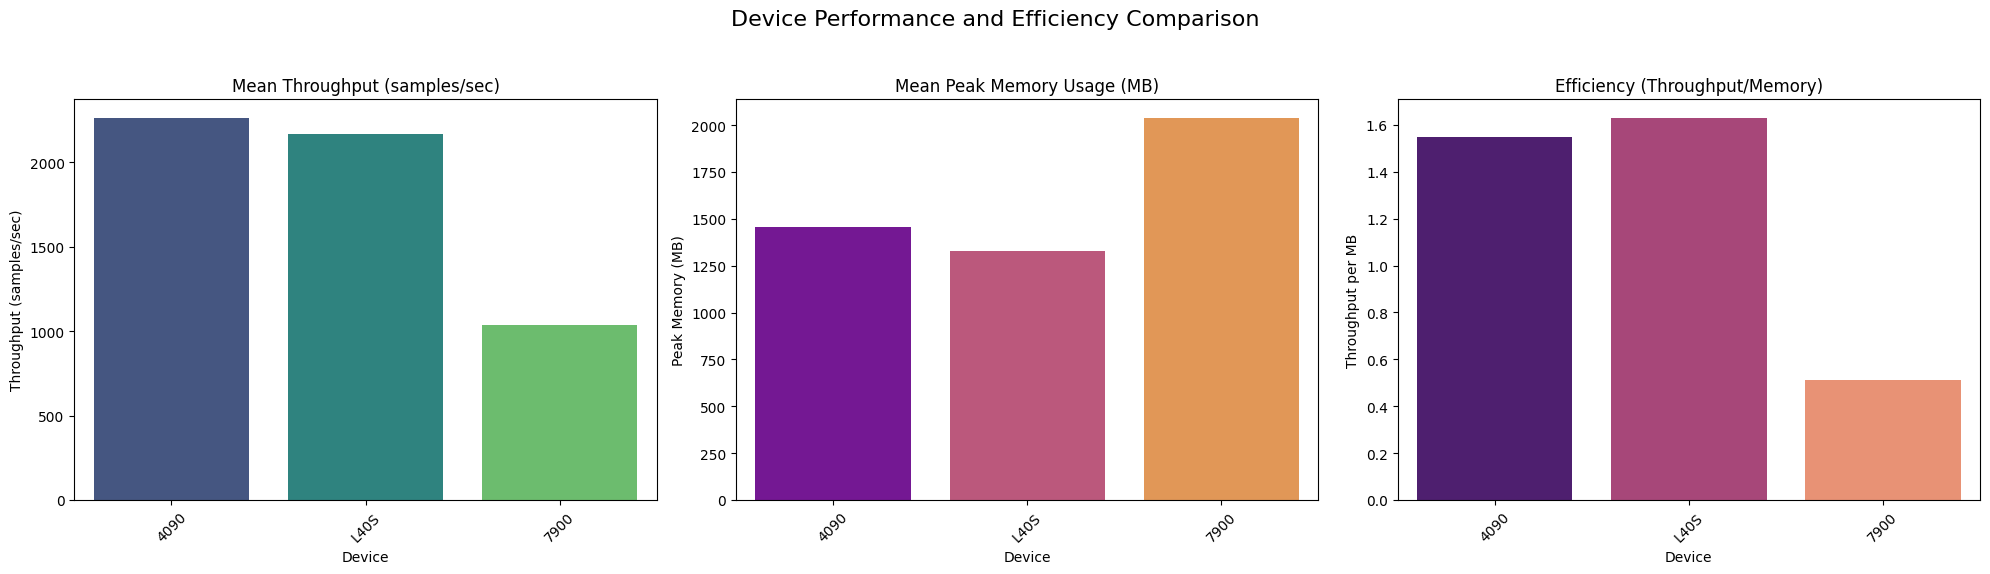

In [6]:
import seaborn as sns

import matplotlib.pyplot as plt

if not df.empty:
    # Group by device and calculate the mean for performance and memory metrics
    device_summary = df.groupby('device').agg(
        mean_throughput=('throughput_samples_per_sec', 'mean'),
        mean_peak_memory_mb=('peak_memory_mb', 'mean')
    ).reset_index()

    # Calculate an efficiency score: throughput per megabyte of peak memory
    device_summary['efficiency_throughput_per_mb'] = device_summary['mean_throughput'] / device_summary['mean_peak_memory_mb']

    # Sort by mean throughput for clearer visualization
    device_summary = device_summary.sort_values(by='mean_throughput', ascending=False)

    print("Device Performance and Efficiency Summary:")
    print(device_summary)

    # Create subplots for visualization
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('Device Performance and Efficiency Comparison', fontsize=16)

    # Plot Mean Throughput
    sns.barplot(data=device_summary, x='device', y='mean_throughput', ax=axes[0], palette='viridis')
    axes[0].set_title('Mean Throughput (samples/sec)')
    axes[0].set_ylabel('Throughput (samples/sec)')
    axes[0].set_xlabel('Device')
    axes[0].tick_params(axis='x', rotation=45)

    # Plot Mean Peak Memory
    sns.barplot(data=device_summary, x='device', y='mean_peak_memory_mb', ax=axes[1], palette='plasma')
    axes[1].set_title('Mean Peak Memory Usage (MB)')
    axes[1].set_ylabel('Peak Memory (MB)')
    axes[1].set_xlabel('Device')
    axes[1].tick_params(axis='x', rotation=45)

    # Plot Efficiency
    sns.barplot(data=device_summary, x='device', y='efficiency_throughput_per_mb', ax=axes[2], palette='magma')
    axes[2].set_title('Efficiency (Throughput/Memory)')
    axes[2].set_ylabel('Throughput per MB')
    axes[2].set_xlabel('Device')
    axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("DataFrame is empty. No comparison can be made.")